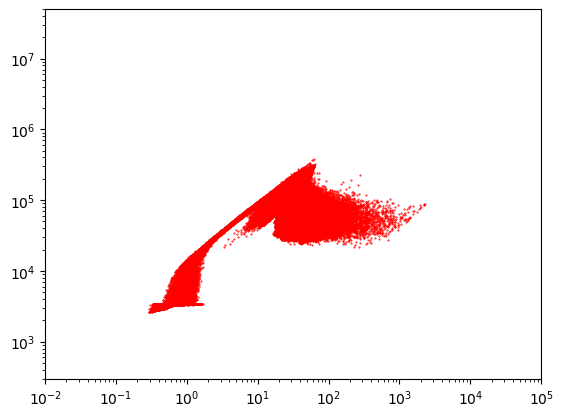

In [4]:
# encoding: utf-8

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import h5py

dir = '/Users/maedarn/Dropbox/analysis/low_metal/lmt_m2/'
im=128
jm=128
km=128
num=18
nstep = 20
#itime = 1
#ftime = 104
itime = 91
ftime = 91
timejump=1
#folder1="Phiwv"  #+ str(np.int(sample_frequency)) 
#older2="Phiexa"  #+ str(np.int(sample_frequency)) 
    
#fig, ax = plt.subplots()
fig = plt.figure()
#ax = fig.add_subplot(111)
#ax1 = fig.add_subplot(111)
ax = fig.add_subplot(1,1,1)
for i in range(itime,ftime +1,timejump): #最後は含まない
#h5file1 = h5py.File(dir1+'NAllHDF'+"%03.f"%(i)+'.h5',"r")
    with h5py.File(dir+'wHDFALL'+"%03.f"%(i)+'.h5',"r")as f:
        RHO  = f["RHO/RHO"]
        Vx  = f["V/VX"]
        Vy  = f["V/VY"]
        Vz  = f["V/VZ"]
        P = f["P/P"]
        RHO_1D = np.reshape(RHO, (im*jm*km))
        P_1D = np.reshape(P, (im*jm*km))
        x1=RHO_1D/1.27
        #y1=slice5*116.0
        y1=P_1D*91.0
        #Rho=np.reshape(RHO, im,jm,km)
    
    #mvx=np.mean(RHO)
    #shockedrho = np.where(RHO > 10.0, 1, 0)
    #shockedvx = np.where(abs(Vx) < 40.0, 1, 0)
    #shock = shockedrho + shockedvx
    #shocked_Region = np.where(shock >= 1, 1, 0)
    
    #Vx_sh=Vx * shocked_Region 
    
    #ax.set_xlabel('n')  # x軸ラベル
    #ax.set_ylabel('p/k_{B}')  # y軸ラベル
    #ax.set_title(r'$\sin(x)$ and $\cos(x)$') # グラフタイトル
    # ax.set_aspect('equal') # スケールを揃える
    #ax.grid()            # 罫線
    #plt.yscale('log')
    #plt.xscale('log')
    #plt.plot(x1, y1)
    #matplotlib.pyplot.scatter
    plt.scatter(x1, y1, s=0.2,color='red')# norm=LogNorm())#, s=20)#, c=None, marker='o', cmap=None, norm=None,vmin=None, vmax=None, alpha=None, linewidths=None,verts=None, edgecolors=None, hold=None, data=None,**kwargs)
    ax.set_yscale('log')  # y軸をlogスケールで描く
    ax.set_xscale('log')  # x軸をlogスケールで描く
    ax.set_xlim([0.01, 100000]) # x方向の描画範囲を指定
    ax.set_ylim([300, 50000000])    # y方向の描画範囲を指定
    #p = plt.plot(data01,data02, "black", linestyle='dashed') # normal way
    #ax.plot(t, y1, color=c1, label=l1)
    #ax.plot(t, y2, color=c2, label=l2)
    #ax.plot(t, y3, color=c3, label=l3)
    #ax.plot(t, y4, color=c4, label=l4)
    #ax.legend(loc=0)    # 凡例
    #fig.tight_layout()  # レイアウトの設定
    plt.savefig(dir+'hoge.png',transparent=True) # 画像の保存
    plt.show()
                    
                    
    #plt.savefig("foo.png")
    
    
   
      


[  3.88349515   6.47806034  10.80605593  18.0255877   30.06849253
  50.15726854  83.6673666  139.56557918 232.8094176  388.34951456] 321231.25 [  982283.46456693  1638547.57492683  2733262.0899633   4559355.96057633
  7605464.12712367 12686678.79611077 21162655.71507696 35301437.36689977
 58886346.63565974 98228346.4566929 ]
[1644.60368058  985.91400452  591.03991788  354.31912208  212.40873327
  127.33569023   76.33574079   45.76207434   27.43364283   16.44603681] [30.         23.22791048 17.98452751 13.9247665  10.78144099  8.34767821
  6.46330407  5.00430161  3.874649    3.        ]


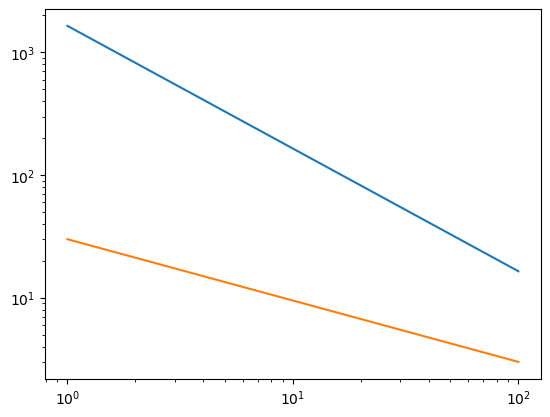

In [29]:
import matplotlib.pyplot as plt
import numpy as np

#---parameters---
M=10.0
cs0=10.0
v0=M*cs0 #100.0
T0=10000.0
gmm=5.0/3.0
mu=1.27
Z=0.0001
Tline=100.0
delta=0.2
#---parameters---

#n0 = 1.0#np.linspace( -4, 3, 8)
n0log = np.linspace( 0.0, 2.0,10)
n0=10.0**(n0log)
n1 = n0*(gmm+1.0)*M*M/((gmm-1.0)*M*M+2.0)
T1 = T0*(2.0*gmm*M*M-(gmm-1.0))*((gmm-1.0)*M*M+2.0)/((gmm+1.0)**2*M*M)
p1=n1*T1/mu
print(n1,T1,p1)

tcool = 0.4*(Z/1.0)**(-1.0)*(n1/1.0)**(-3.0/2.0)*(p1/1.e5)**(0.5)*np.exp(0.01*(Tline/100.0)*(n1/1.0)*(p1/1.e5)**(-1.0))
tg=30.0*(delta/0.2)**(-0.1)*(n0/1.0)**(-0.5)*(M/10)**(-0.5)
print(tcool,tg)

plt.plot(n0, tcool)
plt.plot(n0, tg)
plt.xscale('log')
plt.yscale('log')
plt.show()

/var/folders/kw/hmy8d3gn14j8321d_1qs3ry40000gn/T/ipykernel_34779/3247971761.py:14: RuntimeWarning: divide by zero encountered in power
  n=1.1*1.e-2*(L/1.e37)**(6.0/35.0)*(n0/1.0)**(19.0/35.0)*(t/(1.e6*3.0*1.e7))**(-22.0/35.0)*(1-x)**(-2.0/5.0)


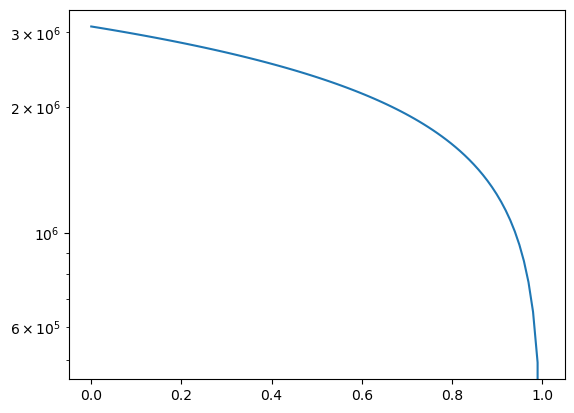

In [4]:
import matplotlib.pyplot as plt
import numpy as np

#---parameters---
L=1.e37
n0=1.0
t=1.e6*3.0*1.e7
R=42.0*(L/1.e37)**(1.0/5.0)*(n0/1.0)**(-1.0/5.0)*(t/(1.e6*3.0*1.e7))**(3.0/5.0)
#---parameters---


x = np.linspace( 0.0, 1.0,100)
T=3.1*1.e6*(L/1.e37)**(8.0/35.0)*(n0/1.0)**(2.0/35.0)*(t/(1.e6*3.0*1.e7))**(-6.0/35.0)*(1-x)**(2.0/5.0)
n=1.1*1.e-2*(L/1.e37)**(6.0/35.0)*(n0/1.0)**(19.0/35.0)*(t/(1.e6*3.0*1.e7))**(-22.0/35.0)*(1-x)**(-2.0/5.0)



plt.plot(x, T)
#plt.xscale('log')
plt.yscale('log')
plt.show()

In [ ]:
v=(125.0/154.0/3.14)**0.2*()